In [ ]:
import mne
import numpy as np
from collections import Counter

# Load 
# Sampling rate = 1000 Hz, analog highpass = 0.1 Hz, 32 channels,
# original reference = FCz, EOG = HEOG/VEOG, misc = ['41']
raw = mne.io.read_raw_brainvision(
    "/work/EEG_lab/own_experiments_data/group6_own.vhdr",
    eog=['HEOG', 'VEOG'],
    misc=['41'],
    preload=True
)

# Montage 
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, verbose=False)

# Channel selection (keeping all EEG channels)
raw.info["bads"] = []
raw.pick(picks="eeg", exclude="bads")

# Filter, then reference 
raw.filter(.1, 40)
raw.set_eeg_reference('average', projection=False, verbose=False)

# Epoching parameters 
tmin, tmax = -0.4, 0.5
reject = {'eeg': 150e-6}
picks = ['eeg']
srate = raw.info['sfreq']
max_rt_samples = int(1.5 * srate)

# Crop into the two blocks 
# Real face trials end near sample 416468. The word block begins near 429954.
crop_end = (416468 + 500) / srate
raw_face = raw.copy().crop(tmax=crop_end)
 
crop_start = (429954 - 400) / srate
raw_word = raw.copy().crop(tmin=crop_start)

# True for each stim event with a correct-response sample within the RT window.
def get_correct_mask(events, correct_samples, stim_codes, max_rt_samples):
    mask = np.zeros(len(events), dtype=bool)
    for i, e in enumerate(events):
        if e[2] in stim_codes:
            mask[i] = np.any(
                (correct_samples > e[0]) &
                (correct_samples <= e[0] + max_rt_samples)
            )
    return mask

# Drop a trigger if a response trigger follows within max_collision_samples
def drop_stim_response_collisions(events, stim_codes, resp_codes, max_collision_samples):
    drop = set()
    n = len(events)
    for i, e in enumerate(events):
        if e[2] in stim_codes:
            for j in range(i + 1, n):
                dt = events[j, 0] - e[0]
                if dt > max_collision_samples:
                    break
                if events[j, 2] in resp_codes:
                    drop.add(i)
                    break
    keep = [i for i in range(n) if i not in drop]
    return events[keep]

# Face events: remove stim/response collisions
event_face, _ = mne.events_from_annotations(raw_face)

collision_win = int(0.05 * srate)  # 50 ms
event_face_clean = drop_stim_response_collisions(event_face, [30, 31], [10, 11], collision_win)

# Face epochs 
correct_face = event_face_clean[event_face_clean[:, 2] == 10, 0]
epochs_face = mne.Epochs(
    raw_face, events=event_face_clean,
    event_id={"face/congruent": 30, "face/incongruent": 31},
    reject=reject, tmin=tmin, tmax=tmax,
    baseline=(tmin, 0), picks=picks, preload=True,
)
mask_face = get_correct_mask(event_face_clean, correct_face, [30, 31], max_rt_samples)
epochs_face.drop(~mask_face[epochs_face.selection], reason='no_correct_response')
 
# Word events: strip leaked face codes before masking 
event_word, _ = mne.events_from_annotations(raw_word)
event_word_clean = event_word[~np.isin(event_word[:, 2], [30, 31])]
correct_word = event_word_clean[event_word_clean[:, 2] == 10, 0]

# Word epochs 
epochs_word = mne.Epochs(
    raw_word, events=event_word_clean,
    event_id={"word/congruent": 20, "word/incongruent": 21},
    reject=reject, tmin=tmin, tmax=tmax,
    baseline=(tmin, 0), picks=picks, preload=True,
)
mask_word = get_correct_mask(event_word_clean, correct_word, [20, 21], max_rt_samples)
epochs_word.drop(~mask_word[epochs_word.selection], reason='no_correct_response')
  
# Combine 
epochs_clean = mne.concatenate_epochs([epochs_face, epochs_word])
print(epochs_clean)


Extracting parameters from /work/EEG_lab/own_experiments_data/group6_own.vhdr...
Setting channel info structure...
Reading 0 ... 785919  =      0.000 ...   785.919 secs...


/tmp/ipykernel_2128/858183940.py:8: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 33001 samples (33.001 s)

Used Annotations descriptions: [np.str_('Stimulus/S 10'), np.str_('Stimulus/S 11'), np.str_('Stimulus/S 30'), np.str_('Stimulus/S 31')]
Not setting metadata
288 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 288 events and 901 original time points ...
    Rejecting  epoch based on EEG : ['Fp1', 'Fp2', 'FC6', 'CP6', 'P7', 'P3']
    Rejecting  epoch base

/tmp/ipykernel_2128/858183940.py:106: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs_clean = mne.concatenate_epochs([epochs_face, epochs_word])


Not setting metadata
414 matching events found
Applying baseline correction (mode: mean)
<EpochsArray | 414 events (all good), -0.4 – 0.5 s (baseline -0.4 – 0 s), ~85.4 MiB, data loaded,
 'face/congruent': 89
 'face/incongruent': 73
 'word/congruent': 127
 'word/incongruent': 125>


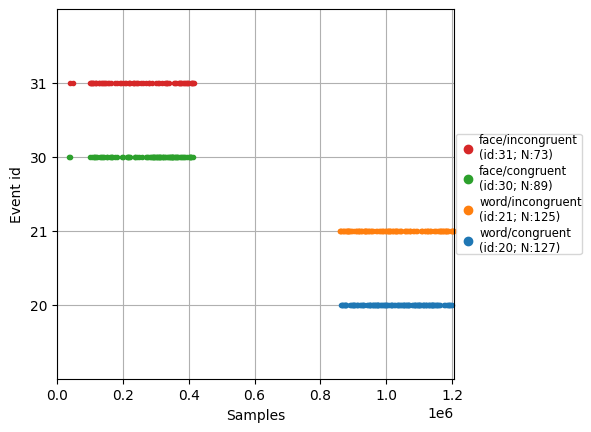

In [3]:
mne.viz.plot_events(
    epochs_clean.events,
    event_id={"face/congruent": 30, "face/incongruent": 31,
              "word/congruent": 20, "word/incongruent": 21}
);

The central gap of no events caused by renumbering of samples by mne. Not an error.

In [4]:
epochs_clean.save(fname="participant-own-long-epo.fif", overwrite=True)


Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


[PosixPath('/work/MikkelKrøjerSvendsen#1451/eeg_emotional_stroop/participant-own-long-epo.fif')]